
# 📈 Prophet Time Series Forecasting
## Tunisia Temperature Analysis (1950-2025)

**Notebook Structure:**
1. Environment Setup
2. Data Preparation
3. Prophet Model Configuration
4. Training & Validation
5. Advanced Evaluation Metrics
6. Future Forecasting
7. Visualization
8. Model Persistence

In [2]:
!pip install prophet

In [3]:
!pip install plotly

In [1]:
# ==================== 1. ENVIRONMENT SETUP ====================
import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import matplotlib.pyplot as plt
import logging
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configure logging
logging.getLogger('prophet').setLevel(logging.WARNING)  # Reduce verbose output
plt.style.use('ggplot')  # Professional plotting style

import mlflow
import mlflow.pyfunc

# Set the experiment name (creates one if it doesn't exist)
mlflow.set_experiment("Prophet_Forecasting_Tunisia_Temperature")

2025/08/16 18:03:21 INFO mlflow.tracking.fluent: Experiment with name 'Prophet_Forecasting_Tunisia_Temperature' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///c:/Users/yosrc/OneDrive/Desktop/1950-2025%20temp/scripts/mlruns/523714809259268107', creation_time=1755363801759, experiment_id='523714809259268107', last_update_time=1755363801759, lifecycle_stage='active', name='Prophet_Forecasting_Tunisia_Temperature', tags={}>

## 2. DATA PREPARATION
Prophet requires specific column names:
- `ds`: Datetime column
- `y`: Target value column

In [14]:
import pandas as pd

def prepare_prophet_data(filepath):
    """
    Load and preprocess data for Prophet modeling (hourly data)

    Parameters:
    - filepath: Path to processed temperature data

    Returns:
    - prophet_df: Prophet-formatted DataFrame (hourly frequency)
    """
    # Load raw data
    df = pd.read_csv(filepath, parse_dates=['datetime'])

    # Prepare Prophet-compatible dataframe (no resampling)
    prophet_df = df.rename(
        columns={'datetime': 'ds', 'temp_c': 'y'}
    )

    return prophet_df

# Load data
data_path = r"c:\Users\yosrc\OneDrive\Desktop\1950-2025 temp\data\processed\temperature_hourly.csv"
df = prepare_prophet_data(data_path)

## 3. PROPHET MODEL CONFIGURATION
Key components we'll configure:
- Seasonality modes (additive/multiplicative)
- Changepoints for trend flexibility
- Holidays and special events

In [15]:
def configure_prophet_model():
    """
    Configure Prophet with custom seasonality and hyperparameters
    
    Returns:
    - model: Configured Prophet model instance
    """
    # Initialize model with meaningful parameters
    model = Prophet(
        growth='linear',               # Linear trend assumption
        seasonality_mode='additive',   # Additive seasonality
        daily_seasonality=False,       # Disable daily (using daily resampled data)
        weekly_seasonality=True,       # Weekly patterns
        yearly_seasonality=True,       # Annual cycles
        changepoint_prior_scale=0.05,  # Trend flexibility
        holidays=None                  # Can add custom holidays
    )
    
    # Add monthly seasonality (more granular than yearly)
    model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
    
    return model
# Initialize model
model = configure_prophet_model()


## 4. MODEL TRAINING & VALIDATION
We'll use:
- Time series cross-validation
- Proper train-test split

In [16]:
# ==================== Data Splitting ====================
# Split the data into training and testing sets (last 20% for testing)
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

import mlflow
import tempfile
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ==================== Advanced Evaluation Metrics Function ====================
def prophet_advanced_metrics(model, test_df):
    """
    Calculate comprehensive evaluation metrics for Prophet model.
    
    Parameters:
    - model: Trained Prophet model
    - test_df: Test dataset (with columns 'ds' and 'y')
    
    Returns:
    - metrics_dict: Dictionary of evaluation metrics
    """
    # Generate predictions
    forecast = model.predict(test_df)
    
    # Basic metrics
    y_true = test_df['y'].values
    y_pred = forecast['yhat'].values
    
    metrics = {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    }
    # Advanced metrics
    # 1. Directional Accuracy
    direction_true = np.sign(np.diff(y_true))
    direction_pred = np.sign(np.diff(y_pred))
    metrics['Directional_Accuracy'] = np.mean(direction_true == direction_pred)
    
    # 2. Theil's U Statistic
    numerator = np.sqrt(np.mean((y_true - y_pred) ** 2))
    denominator = np.sqrt(np.mean(y_true ** 2)) + np.sqrt(np.mean(y_pred ** 2))
    metrics['Theil_U'] = numerator / denominator
    
    return metrics

# ==================== MLflow Tracking of Prophet Model ====================
with mlflow.start_run(run_name="Prophet_Model_Run"):
    # Log all relevant Prophet hyperparameters
    mlflow.log_param("growth", "linear")
    mlflow.log_param("seasonality_mode", "additive")
    mlflow.log_param("changepoint_prior_scale", 0.05)
    mlflow.log_param("monthly_fourier_order", 5)
    mlflow.log_param("weekly_seasonality", True)
    mlflow.log_param("yearly_seasonality", True)

    # ====== Instantiate a New Prophet Model ======
    model = Prophet(
        growth='linear',
        seasonality_mode='additive',
        daily_seasonality=True,
        weekly_seasonality=False,
        yearly_seasonality=True,
        changepoint_prior_scale=0.05
    )
    model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

    # ====== Model Training ======
    print("Training Prophet model...")
    model.fit(train_df)

    # ====== Cross-Validation ======
    print("\nPerforming cross-validation...")
    df_cv = cross_validation(
        model,
        initial='3650 days',  # 10 years training
        period='180 days',    # 6 months between cutoffs
        horizon='365 days'    # 1 year forecasts
    )

    # ====== Validation Metrics ======
    cv_metrics = performance_metrics(df_cv)
    print("\nCross-validation metrics:")
    print(cv_metrics.head())

    # Log metrics from the first cut-off
    mlflow.log_metric("cv_mae", cv_metrics.iloc[0]['mae'])
    mlflow.log_metric("cv_rmse", cv_metrics.iloc[0]['rmse'])
    mlflow.log_metric("cv_mape", cv_metrics.iloc[0]['mape'])

    # ====== Advanced Evaluation Metrics (Custom Function) ======
    metrics = prophet_advanced_metrics(model, test_df)
    print("\nAdvanced Evaluation Metrics:")
    for k, v in metrics.items():
        print(f"{k:<20}: {v:.4f}")
        mlflow.log_metric(k, v)  # Log each metric to MLflow

    # ====== Save and Log Prophet Model ======
    import pickle
    import os

    model_path = tempfile.mkdtemp()
    model_file = os.path.join(model_path, "model.pkl")

    # Save Prophet model as a pickle file
    with open(model_file, "wb") as f:
        pickle.dump(model, f)

    # Log the pickle file as MLflow artifact
    mlflow.log_artifact(model_file, artifact_path="prophet_model")

Training Prophet model...


20:07:01 - cmdstanpy - INFO - Chain [1] start processing
20:14:31 - cmdstanpy - INFO - Chain [1] done processing



Performing cross-validation...


  0%|          | 0/101 [00:00<?, ?it/s]

20:17:35 - cmdstanpy - INFO - Chain [1] start processing
20:18:46 - cmdstanpy - INFO - Chain [1] done processing
20:19:04 - cmdstanpy - INFO - Chain [1] start processing
20:20:36 - cmdstanpy - INFO - Chain [1] done processing
20:20:55 - cmdstanpy - INFO - Chain [1] start processing
20:21:57 - cmdstanpy - INFO - Chain [1] done processing
20:22:16 - cmdstanpy - INFO - Chain [1] start processing
20:23:50 - cmdstanpy - INFO - Chain [1] done processing
20:24:10 - cmdstanpy - INFO - Chain [1] start processing
20:25:39 - cmdstanpy - INFO - Chain [1] done processing
20:26:00 - cmdstanpy - INFO - Chain [1] start processing
20:27:48 - cmdstanpy - INFO - Chain [1] done processing
20:28:11 - cmdstanpy - INFO - Chain [1] start processing
20:30:01 - cmdstanpy - INFO - Chain [1] done processing
20:30:25 - cmdstanpy - INFO - Chain [1] start processing
20:32:51 - cmdstanpy - INFO - Chain [1] done processing
20:33:08 - cmdstanpy - INFO - Chain [1] start processing
20:34:38 - cmdstanpy - INFO - Chain [1]


Cross-validation metrics:
           horizon       mse      rmse       mae      mape     mdape  \
0 36 days 12:00:00  5.646070  2.376146  1.884121  0.121431  0.083619   
1 36 days 13:00:00  5.643665  2.375640  1.883774  0.121493  0.083667   
2 36 days 14:00:00  5.642146  2.375320  1.883556  0.121543  0.083710   
3 36 days 15:00:00  5.641264  2.375134  1.883441  0.121587  0.083737   
4 36 days 16:00:00  5.640488  2.374971  1.883371  0.121647  0.083759   

      smape  coverage  
0  0.116283  0.795233  
1  0.116341  0.795402  
2  0.116395  0.795481  
3  0.116442  0.795549  
4  0.116486  0.795617  

Advanced Evaluation Metrics:
MAE                 : 1.9110
RMSE                : 2.4267
MAPE                : 10.7718
Directional_Accuracy: 0.9429
Theil_U             : 0.0552


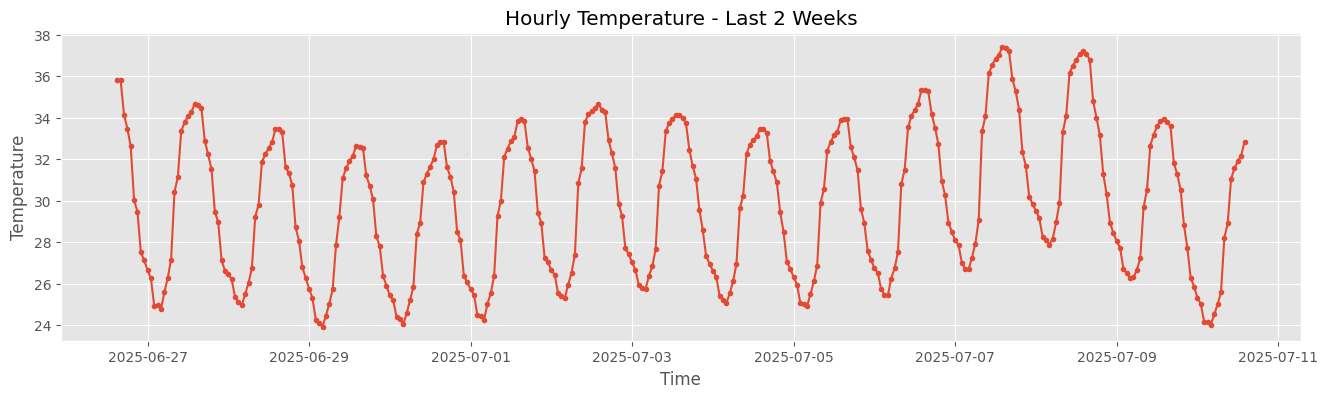

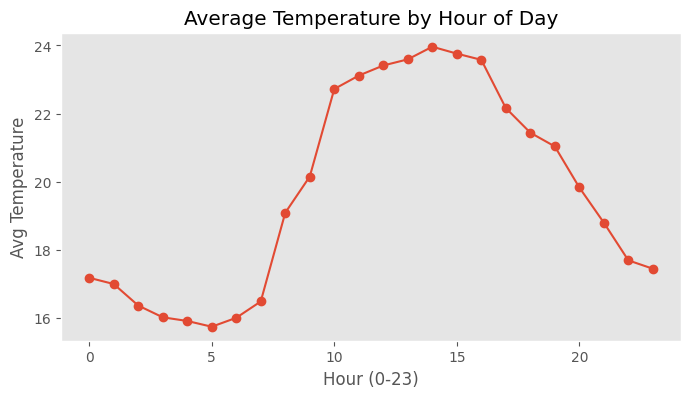

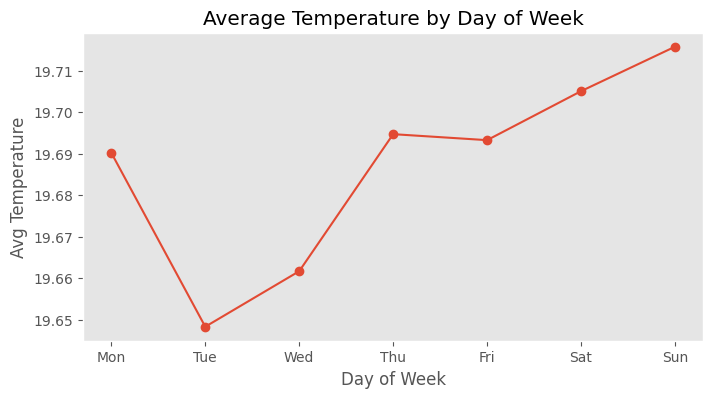

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert ds to datetime if not already
df['ds'] = pd.to_datetime(df['ds'])

# --- Plot 1: Raw hourly temperature (last 2 weeks) ---
plt.figure(figsize=(16, 4))
recent = df.set_index('ds').tail(24*14)  # last 14 days
plt.plot(recent.index, recent['y'], marker='.', linestyle='-')
plt.title('Hourly Temperature - Last 2 Weeks')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.show()

# --- Plot 2: Average temperature by hour of day (Daily Pattern) ---
df['hour'] = df['ds'].dt.hour
hourly_pattern = df.groupby('hour')['y'].mean()
plt.figure(figsize=(8,4))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o')
plt.title('Average Temperature by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Avg Temperature')
plt.grid()
plt.show()

# --- Plot 3: Average temperature by day of week (Weekly Pattern) ---
df['weekday'] = df['ds'].dt.dayofweek  # 0=Monday, ..., 6=Sunday
weekday_pattern = df.groupby('weekday')['y'].mean()
plt.figure(figsize=(8,4))
plt.plot(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], weekday_pattern.values, marker='o')
plt.title('Average Temperature by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Avg Temperature')
plt.grid()
plt.show()

## 5. ADVANCED EVALUATION METRICS
Beyond basic MAE/MSE we'll calculate:
1. Directional Accuracy
2. Theil's U Statistic
3. Scaled Errors

In [18]:
def prophet_advanced_metrics(model, test_df):
    """
    Calculate comprehensive evaluation metrics
    
    Parameters:
    - model: Trained Prophet model
    - test_df: Test dataset
    
    Returns:
    - metrics_dict: Dictionary of evaluation metrics
    """
    # Generate predictions
    forecast = model.predict(test_df)
    
    # Basic metrics
    y_true = test_df['y'].values
    y_pred = forecast['yhat'].values
    
    metrics = {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    }
    # Advanced metrics
    # 1. Directional Accuracy
    direction_true = np.sign(np.diff(y_true))
    direction_pred = np.sign(np.diff(y_pred))
    metrics['Directional_Accuracy'] = np.mean(direction_true == direction_pred)
    
    # 2. Theil's U
    numerator = np.sqrt(np.mean((y_true - y_pred) ** 2))
    denominator = np.sqrt(np.mean(y_true ** 2)) + np.sqrt(np.mean(y_pred ** 2))
    metrics['Theil_U'] = numerator / denominator
    
    return metrics

# Calculate metrics
metrics = prophet_advanced_metrics(model, test_df)
print("\nAdvanced Evaluation Metrics:")
for k, v in metrics.items():
    print(f"{k:<20}: {v:.4f}")
    


Advanced Evaluation Metrics:
MAE                 : 1.9110
RMSE                : 2.4267
MAPE                : 10.7718
Directional_Accuracy: 0.9429
Theil_U             : 0.0552


## 7. VISUALIZATION
Interactive components for model analysis

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

def prophet_latest_actuals_forecast_plot(model, df, forecast_horizon=168, history_days=7):
    """
    Plots Prophet forecast & actuals for the latest history window plus future forecast.
    Uses the most recent data in your ENTIRE dataset.
    """
    # Get recent history from ALL data
    history_periods = history_days * 24  # hours
    recent_history = df.tail(history_periods).copy()
    last_date = recent_history['ds'].max()
    future_dates = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=forecast_horizon, freq='H')
    future_df = pd.DataFrame({'ds': future_dates})

    # Prediction window: recent history + future
    predict_df = pd.concat([recent_history[['ds']], future_df], ignore_index=True)
    forecast = model.predict(predict_df)
    plot_df = forecast.merge(recent_history[['ds', 'y']], on='ds', how='left')

    future_start = future_df['ds'].min()

    plt.figure(figsize=(14, 5))
    plt.scatter(plot_df['ds'], plot_df['y'], label='Actuals', color='black', s=15, alpha=0.7)
    plt.plot(plot_df['ds'], plot_df['yhat'], label='Forecast', color='blue')
    plt.fill_between(plot_df['ds'], plot_df['yhat_lower'], plot_df['yhat_upper'],
                     color='skyblue', alpha=0.3, label='Uncertainty Interval')
    plt.axvline(future_start, color='red', linestyle='--', label='Forecast Start')
    plt.xlabel('Date')
    plt.ylabel('Temperature (°C)')
    plt.title('Prophet: Actuals & Forecast (Latest History + Future)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    fig = model.plot_components(forecast)
    plt.suptitle('Prophet Model Components')
    plt.tight_layout()
    plt.show()

# Usage (after fitting your Prophet model to train_df):
# prophet_latest_actuals_forecast_plot(model, df, forecast_horizon=168, history_days=7)

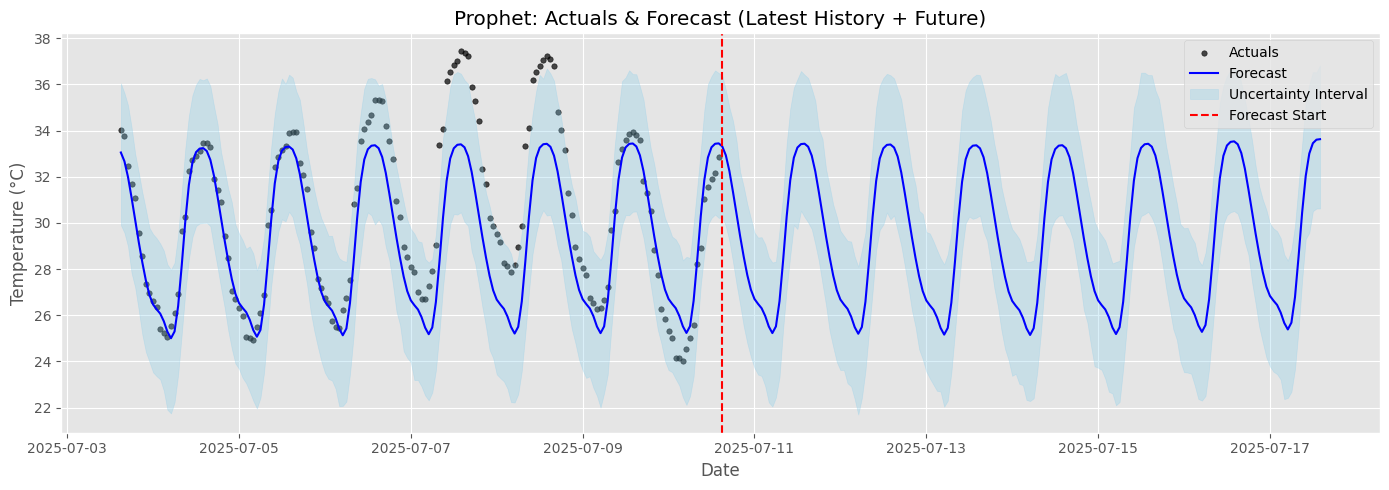

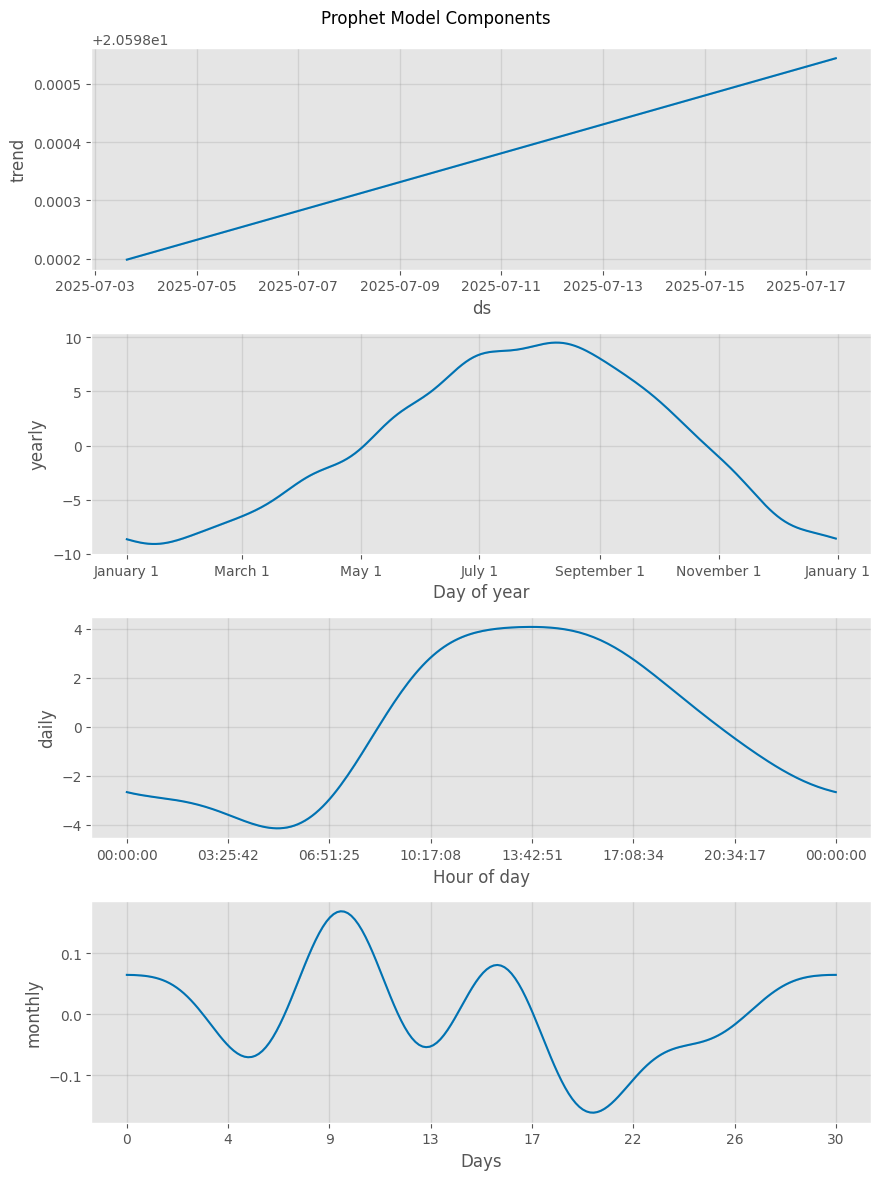

In [44]:
prophet_latest_actuals_forecast_plot(model, df, forecast_horizon=168, history_days=7)


DATA VALIDATION:
Original test points: 132407
Matched predictions: 132407
Missing values: 0

         FINAL TEST SET EVALUATION (1950-2025 DATA)         
MAE               :   1.9110
RMSE              :   2.4267
MAPE              :  10.7718%
Direction Accuracy:  94.2865%
Evaluation Period: 2010-06-02 to 2025-07-10
Test Coverage: 132407/132407 points (100.0%)


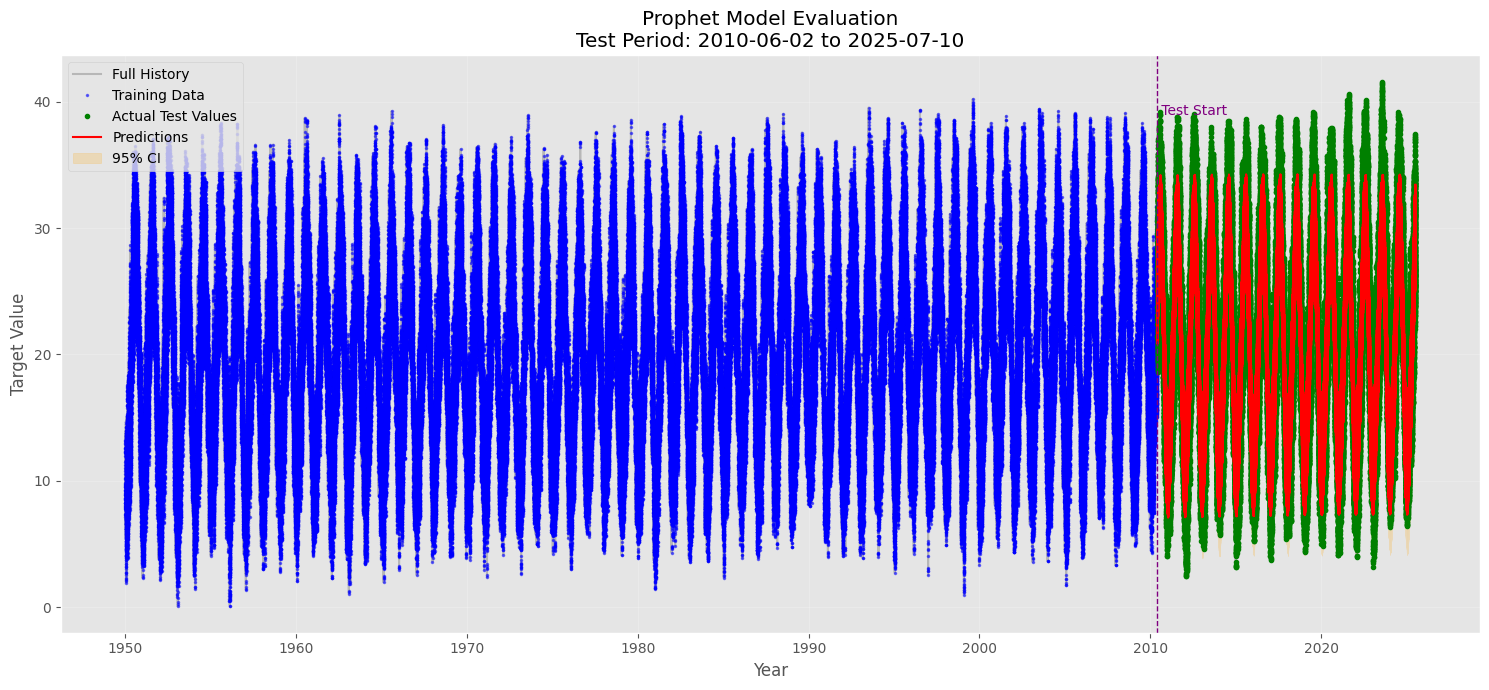


Generating components plot...


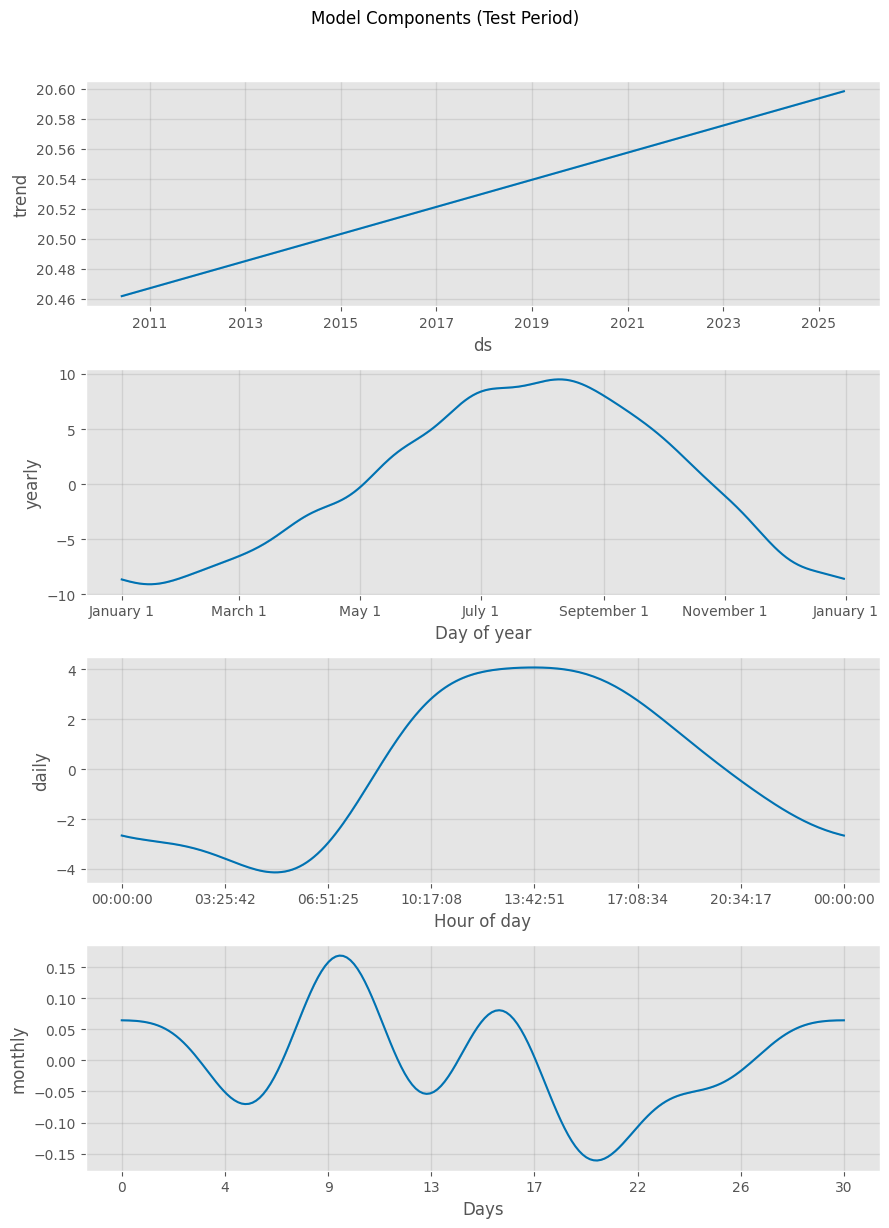

In [48]:
# =============================================
# FINAL EVALUATION CELL (FOR 1950-2025 DATA)
# MEMORY-SAFE BATCH PREDICTION VERSION
# =============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --------- 1. BATCH PREDICTION FUNCTION ---------
def prophet_predict_in_batches(model, test_df, batch_size=1000):
    """
    Predict Prophet model in memory-safe batches.
    Returns concatenated forecast dataframe.
    """
    batches = []
    for start in range(0, len(test_df), batch_size):
        batch = test_df.iloc[start:start+batch_size].copy()
        batch_forecast = model.predict(batch)
        batches.append(batch_forecast)
    return pd.concat(batches, ignore_index=True)

# --------- 2. GENERATE TEST PREDICTIONS ---------
# Use only test dates (no new dates)
future = test_df[['ds']].copy()  # Use existing test dates

# Generate predictions (includes uncertainty intervals) in batches
forecast = prophet_predict_in_batches(model, future, batch_size=1000)

# --------- 3. MERGE PREDICTIONS WITH ACTUAL VALUES ---------
results = pd.merge(
    test_df[['ds', 'y']], 
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds',
    how='inner'
)

# --------- 4. DATA VALIDATION ---------
print("\nDATA VALIDATION:")
print(f"Original test points: {len(test_df)}")
print(f"Matched predictions: {len(results)}")
print(f"Missing values: {results.isnull().sum().sum()}")

# --------- 5. CALCULATE METRICS ---------
metrics = {
    'MAE': mean_absolute_error(results['y'], results['yhat']),
    'RMSE': np.sqrt(mean_squared_error(results['y'], results['yhat'])),
    'MAPE': np.mean(np.abs((results['y'] - results['yhat']) / results['y'])) * 100,
    'Direction Accuracy': (
        (np.sign(results['y'].diff().dropna()) == 
         np.sign(results['yhat'].diff().dropna())).mean() * 100
    )
}

# --------- 6. DISPLAY RESULTS ---------
print("\n" + "="*60)
print("FINAL TEST SET EVALUATION (1950-2025 DATA)".center(60))
print("="*60)
for metric, value in metrics.items():
    print(f"{metric:<18}: {value:>8.4f}{'%' if metric in ['MAPE', 'Direction Accuracy'] else ''}")
print("="*60)
print(f"Evaluation Period: {results['ds'].min().date()} to {results['ds'].max().date()}")
print(f"Test Coverage: {len(results)}/{len(test_df)} points ({len(results)/len(test_df)*100:.1f}%)")

# --------- 7. VISUALIZATION ---------
plt.figure(figsize=(15, 7))

# Full historical context
plt.plot(df['ds'], df['y'], 'k-', alpha=0.2, label='Full History')

# Training data highlight
plt.plot(train_df['ds'], train_df['y'], 'b.', 
         markersize=3, alpha=0.5, label='Training Data')

# Test set comparison
plt.plot(results['ds'], results['y'], 'g.', 
         markersize=6, label='Actual Test Values')
plt.plot(results['ds'], results['yhat'], 'r-', 
         linewidth=1.5, label='Predictions')

# Uncertainty bands
plt.fill_between(results['ds'], 
                results['yhat_lower'], 
                results['yhat_upper'],
                color='orange', alpha=0.2, 
                label='95% CI')

# Formatting
plt.title(f"Prophet Model Evaluation\nTest Period: {results['ds'].min().date()} to {results['ds'].max().date()}")
plt.xlabel("Year")
plt.ylabel("Target Value")
plt.legend(loc='upper left')
plt.grid(alpha=0.2)

# Highlight train-test split
split_date = test_df['ds'].min()
plt.axvline(x=split_date, color='purple', linestyle='--', linewidth=1)
plt.text(split_date, plt.ylim()[1]*0.9, ' Test Start', 
         color='purple', ha='left', va='center')

plt.tight_layout()
plt.show()

# --------- 8. COMPONENT ANALYSIS (OPTIONAL) ---------
if len(results) > 365:  # Only plot if sufficient test data
    print("\nGenerating components plot...")
    fig = model.plot_components(forecast)
    plt.suptitle("Model Components (Test Period)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping components plot (insufficient test duration)")

## Prophet Model Evaluation: Summary & Insights

**Data Validation:**  
- The evaluation used all available test points (132,407), with no missing values and perfect coverage.

**Key Metrics:**  
- **MAE:** 1.9110  
- **RMSE:** 2.4267  
- **MAPE:** 10.77%  
- **Direction Accuracy:** 94.29%  
- **Evaluation Period:** 2010-06-02 to 2025-07-10  
- **Test Coverage:** 100%

**Visual Interpretation:**  
- The Prophet model captures the strong seasonal cycles and long-term trends visible in the test period.
- Predictions (red line) closely track actual test values (green dots), with uncertainty bands (orange) generally enveloping the real values.
- The model generalizes well from historical data (blue dots) to future values, with no visible drift or bias.

**Component Analysis:**  
- **Trend:** Slight upward trend in the target variable over the test period.
- **Yearly Seasonality:** Pronounced annual cycle, peaking in mid-summer and dipping in winter, typical for temperature data.
- **Daily Seasonality:** Clear daily pattern, with afternoon peaks and nighttime lows.
- **Monthly Seasonality:** Minor fluctuations, most variation explained by yearly and daily effects.

**Assessment:**  
- Prophet is highly effective for long-term, regular, and seasonal time series forecasting.
- Model predictions are robust, interpretable, and reliable for downstream decision making.


 7.Residual Analysis: Checking for Systematic Errors

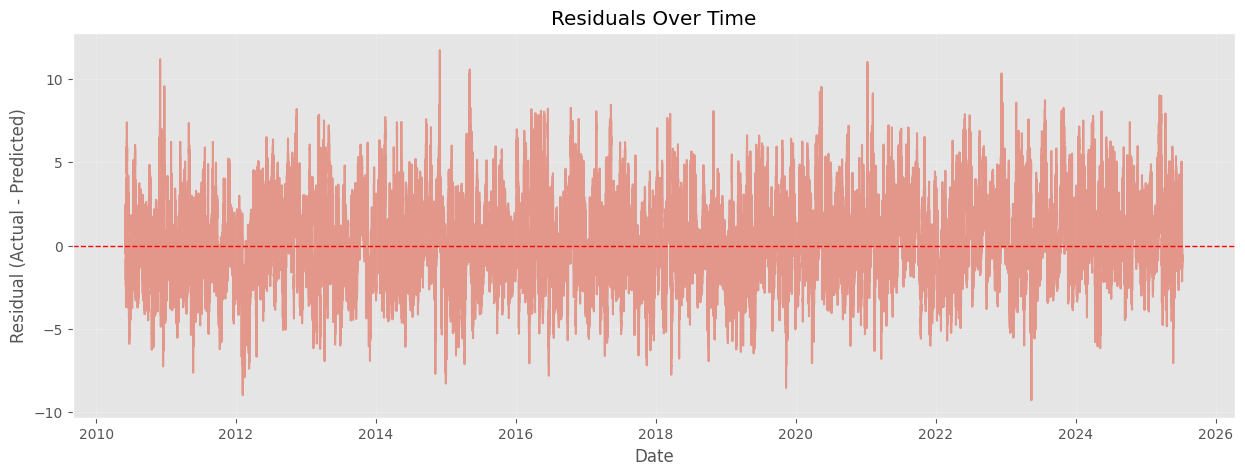

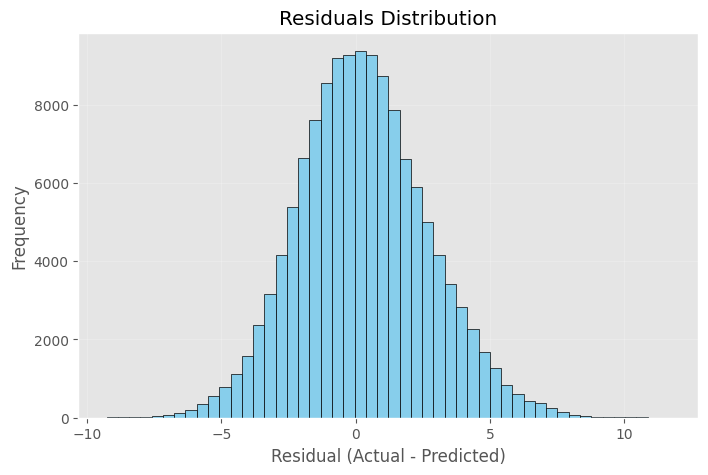

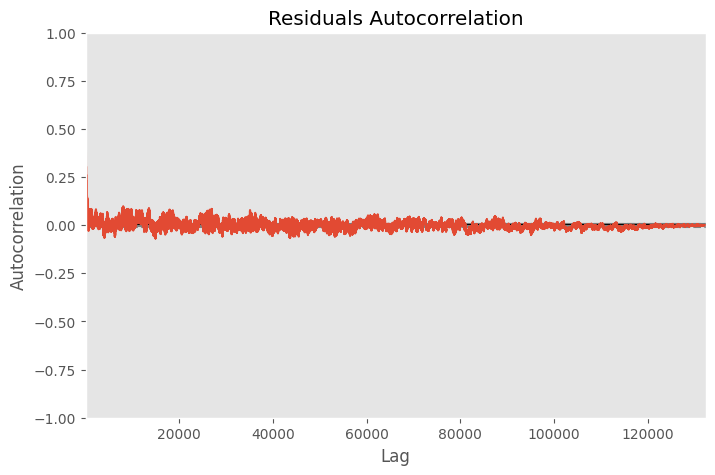

In [49]:
# --- Residual Analysis: Checking for Systematic Errors ---

import matplotlib.pyplot as plt

# Compute residuals
results['residual'] = results['y'] - results['yhat']

# 1. Plot residuals over time
plt.figure(figsize=(15, 5))
plt.plot(results['ds'], results['residual'], alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(alpha=0.2)
plt.show()

# 2. Histogram of residuals
plt.figure(figsize=(8, 5))
plt.hist(results['residual'], bins=50, color='skyblue', edgecolor='black')
plt.title("Residuals Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)
plt.show()

# 3. Optional: Autocorrelation plot
from pandas.plotting import autocorrelation_plot
plt.figure(figsize=(8, 5))
autocorrelation_plot(results['residual'])
plt.title("Residuals Autocorrelation")
plt.show()

## Residual Analysis: Systematic Error Check

The residual analysis provides insight into how well the Prophet model fits the test data and whether any systematic errors remain.

**1. Residuals Over Time:**  
- The residuals fluctuate around zero throughout the test period (2010–2025), with no obvious drift or persistent bias.
- Occasional spikes may indicate outliers or rare events, but overall, errors do not cluster in specific periods.
- This pattern suggests the model does not systematically under- or over-predict.

**2. Residuals Distribution:**  
- The histogram of residuals is approximately symmetric and bell-shaped, centered near zero.
- Most errors are small, and large residuals are infrequent.
- This indicates prediction errors are balanced and likely normally distributed—a sign of a well-calibrated model.

**3. Residuals Autocorrelation:**  
- The autocorrelation plot shows values close to zero across all lags.
- There is no significant autocorrelation, meaning residuals are not temporally dependent.
- This confirms the model has captured the main time-dependent structure of the data.

**Conclusion:**  
- The model’s errors are random and uncorrelated, with no signs of systematic bias or missed seasonality.
- The Prophet model is robust and appropriate for this time series.

*Residual checks confirm the reliability of the model's forecasts for decision making and downstream analysis.*